In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import arviz as az
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

from seisfwi.model import AcousticModel, RockPhysicsGassmann
import seisfwi.defaults as defaults

from utils.vae import VanillaVAE
from utils.project_plots import configure_plot_settings, plot_2d
from utils.project_utils import rockphysic_inversion
from utils import RockPhysicsModel

from HMC_FWI_VAE import get_survey

In [3]:
nz0 = 260
nx0 = 110
nz_res = 15
nx_res = 179
x_res = (np.arange(nx_res) + nx0) * 5.0
z_res = (np.arange(nz_res) + nz0) * 5.0 
extent_res=[x_res[0]/1000, x_res[-1]/1000, z_res[-1]-z_res[0], 0]

In [4]:
configure_plot_settings()
cmap_range     = {'vp': (1400, 4500)}
cmap_range_co2 = {'vp': (-125,  125)}

In [5]:
src_id = 3
rec_id = 1
f0 = 30
noise_flag="-noise-25dB"

# HMC parameters
num_samples = 40000
hmc_temp = 0.025

In [6]:
# Save path
path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id}-geophone-{rec_id}-{f0}Hz{noise_flag}")
path_fig = path / "figures"
path_fig.mkdir(parents=True, exist_ok=True)

In [7]:
model_bl, model_ml, survey = get_survey(f0 = f0, src_id=src_id, rec_id=rec_id, vp_ml_file = f'model/vp_ml_nz346_nx401_5m.npy')
model_fwi = AcousticModel.load(path/"Model-FWI.npz")
sa_fwi = np.load(path/"Model-FWI-Sat.npy").reshape(15, 179)

vp_bl = model_bl.get_model('vp')    
vp_ml = model_ml.get_model('vp')
vp_fwi = model_fwi.get_model('vp') - vp_bl
vp_obs = vp_ml - vp_bl

vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
vp_obs = vp_obs[nz0:nz0+nz_res, nx0:nx0+nx_res]

sa_obs = np.load('model/sa_res_nz15_nx179_5m.npy')

### Rock physics inversion

In [8]:
vp_res = np.load("./model/vp_res_nz15_nx179_5m.npy")

# Parameters for rock physics model
rock_physics_params = RockPhysicsModel(vp_res)

# Gassmann fluid substitution
rockphy = RockPhysicsGassmann(**rock_physics_params)

    Brine properties: K = 2.62 GPa, rho = 1013.5368 kg/m3
      CO2 properties: K = 0.03 GPa, rho = 537.8947 kg/m3
  Mineral properties: K = 36.93 GPa, rho = 2645.1000 kg/m3
  Estimated porosity: phi = 0.1412


In [9]:
sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=True)

Iteration 0001/100: Loss = 10808.15
Iteration 0011/100: Loss = 5399.04
Iteration 0021/100: Loss = 3019.77
Iteration 0031/100: Loss = 2085.38
Iteration 0041/100: Loss = 1747.50
Iteration 0051/100: Loss = 1628.97
Iteration 0061/100: Loss = 1583.51
Iteration 0071/100: Loss = 1564.43
Iteration 0081/100: Loss = 1556.16
Iteration 0091/100: Loss = 1552.36
Iteration 0100/100: Loss = 1550.60


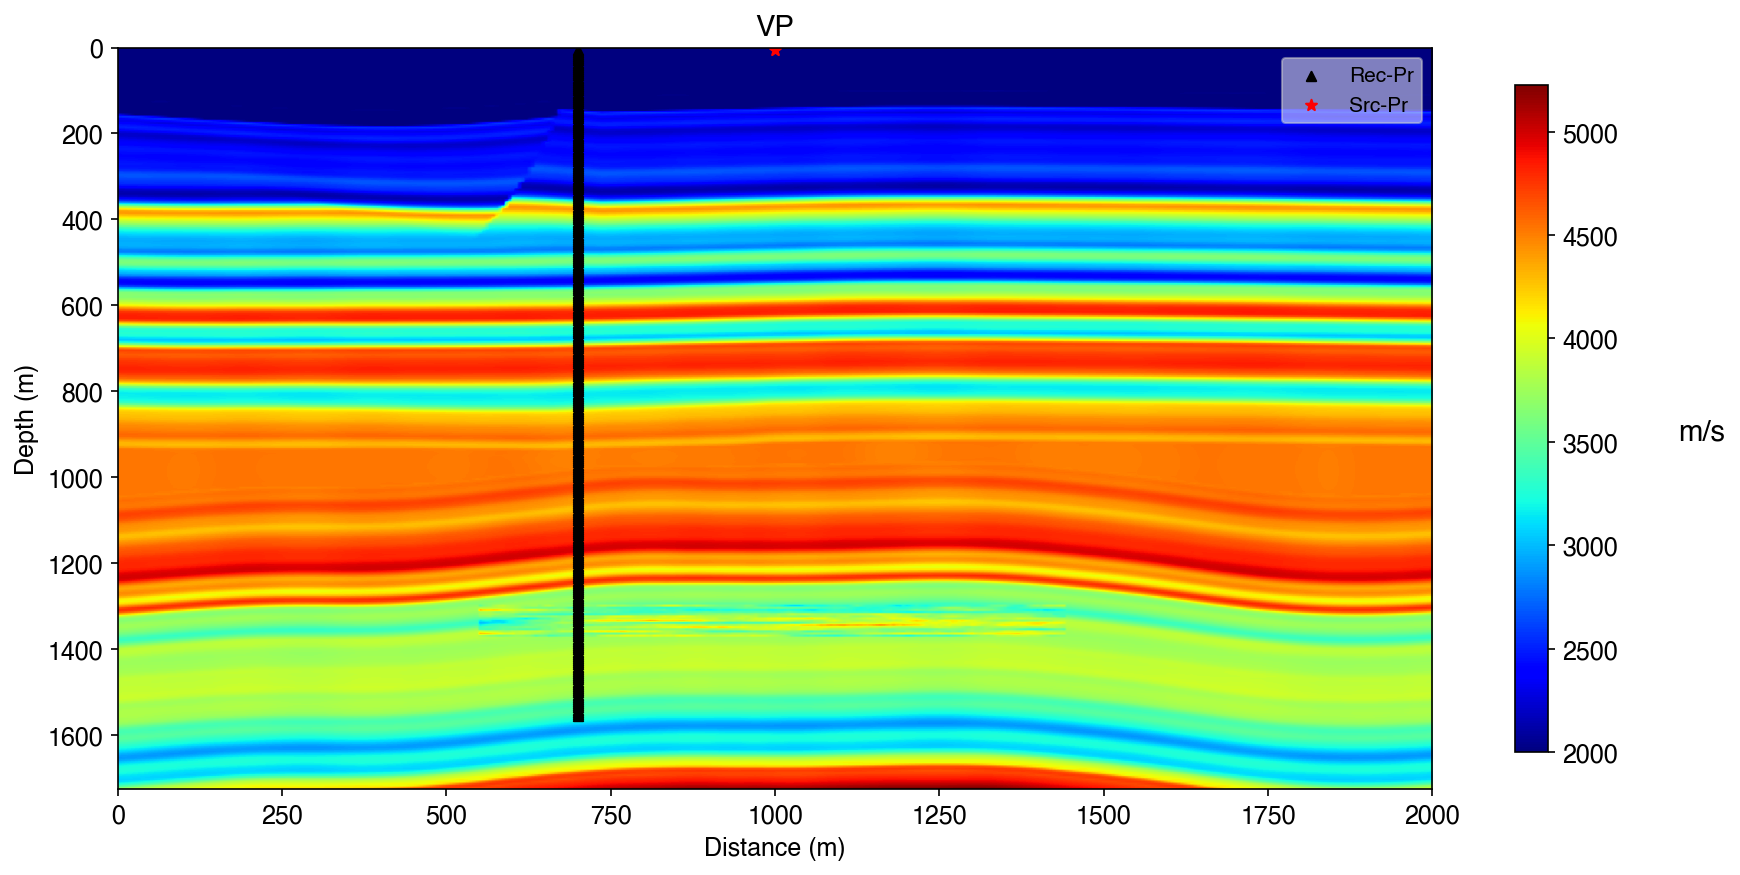

In [10]:
model_bl.plot(survey, cmap='jet', orientation='vertical', figsize=(12, 6))

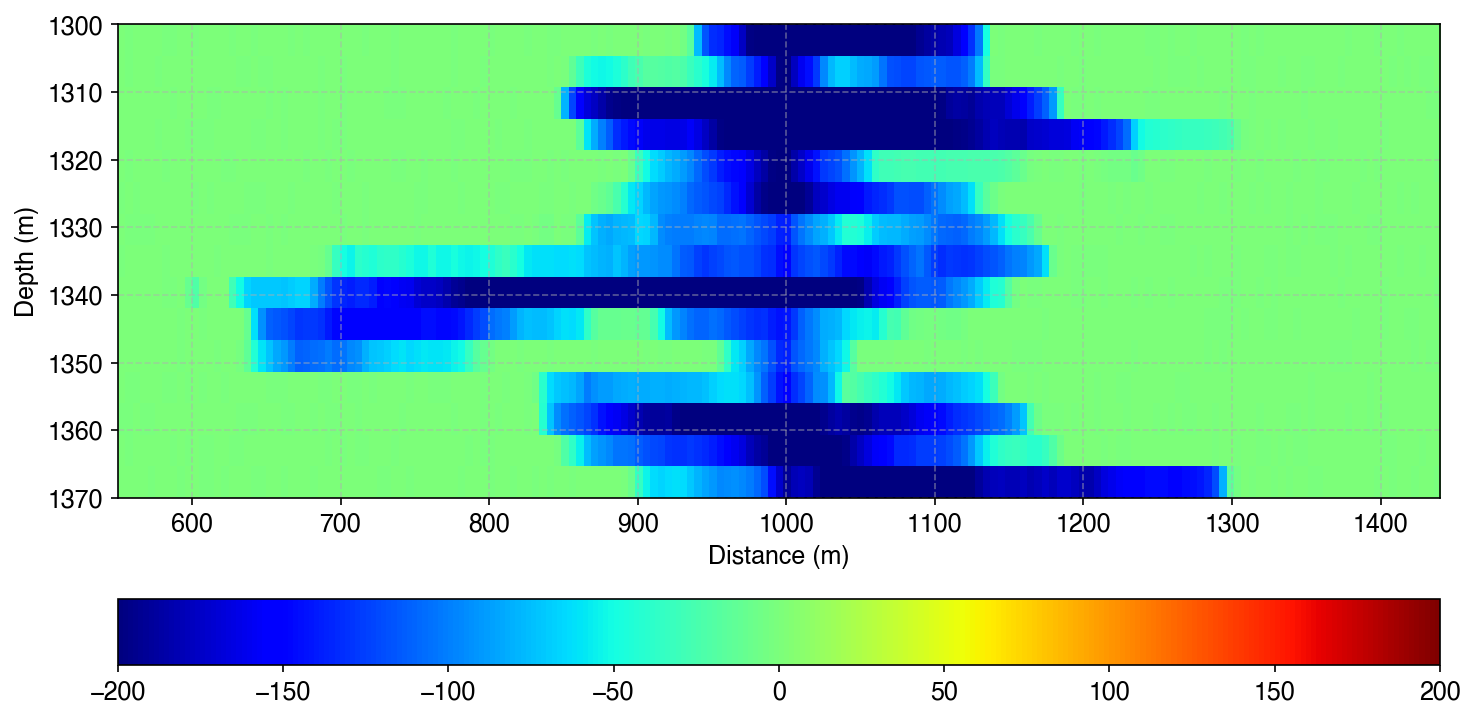

In [11]:
plot_2d(x_res, z_res, vp_obs, vmin=-200, vmax=200, cmap='jet')

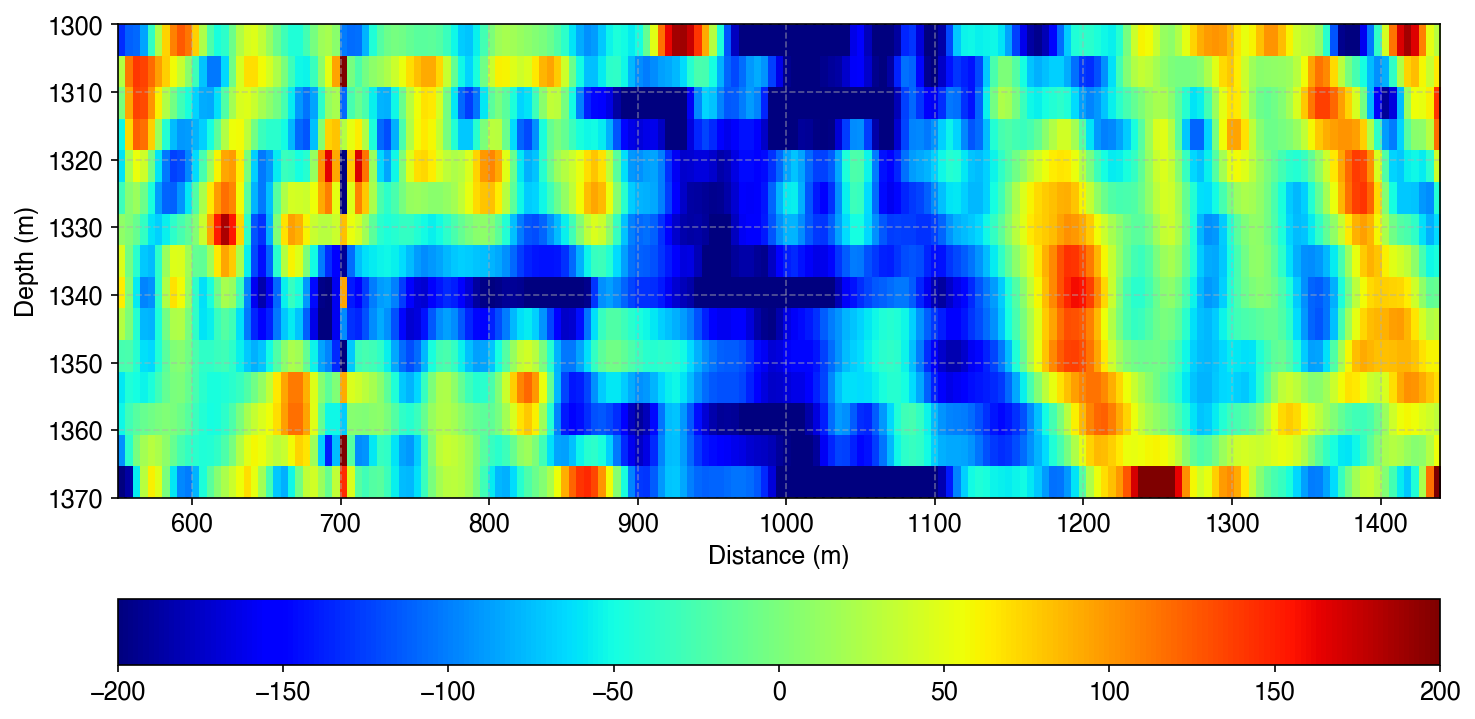

In [12]:
plot_2d(x_res, z_res, vp_fwi, vmin=-200, vmax=200, cmap='jet')

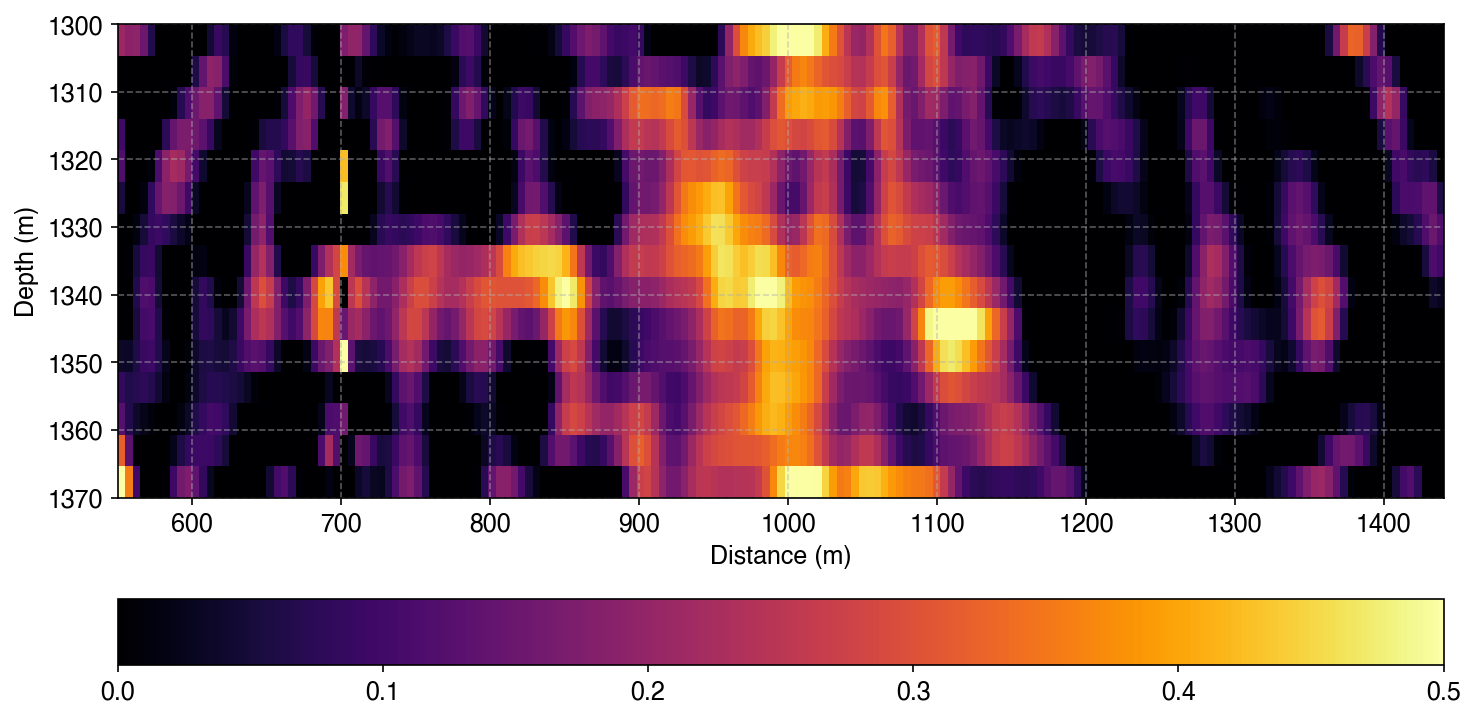

In [13]:
plot_2d(x_res, z_res, sa_fwi_inv, vmin=0, vmax=0.5, cmap='inferno')

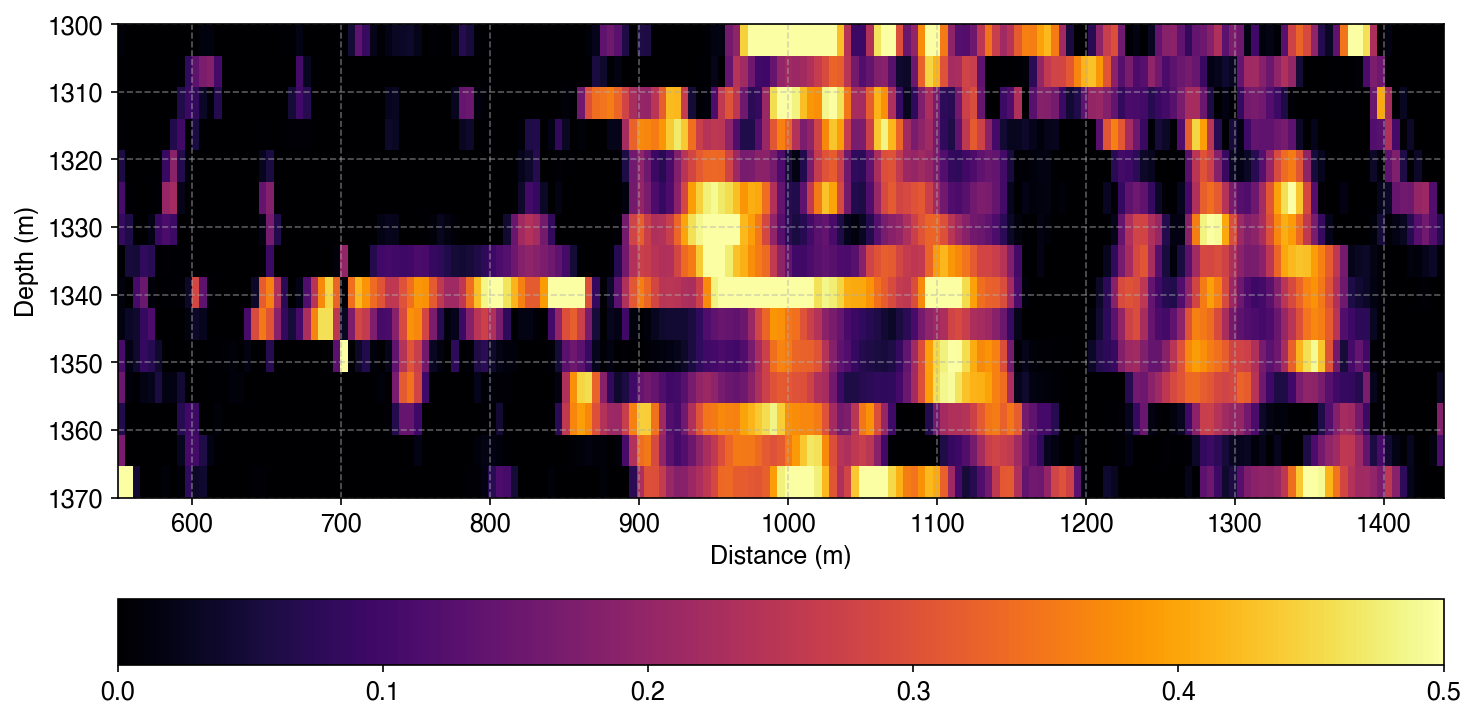

In [14]:
plot_2d(x_res, z_res, sa_fwi, vmin=0, vmax=0.5, cmap='inferno')

In [15]:
# Load VAE Model
kld_weight = 0.000015
in_channels = 1
latent_dim = 64
device = torch.device(defaults.device)
checkpoint_path = f"/net/vision/scr2/haipeng/FWI-HMC/VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"

# Reload the model
model_vae = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(defaults.device)
model_vae.load_state_dict(torch.load(checkpoint_path, map_location=defaults.device))
model_vae.eval()

def decode_in_batches(model, latent_tensor, batch_size):
    """Decode latent vectors in batches to avoid GPU OOM."""
    decoded = []
    n_samples = latent_tensor.shape[0]

    with torch.no_grad():
        for i in tqdm(range(0, n_samples, batch_size), desc="Decoding batches"):
            batch = latent_tensor[i:i + batch_size]
            decoded_batch = model.decode(batch)
            decoded_batch = F.interpolate(decoded_batch, size=(15, 179), mode='bilinear', align_corners=False)
            decoded.append(decoded_batch.cpu())
            
    decoded = torch.cat(decoded, dim=0)
    # compute mean, std, p10, p50, p90
    p10 = torch.quantile(decoded, 0.1, dim=0).numpy().squeeze()
    p50 = torch.quantile(decoded, 0.5, dim=0).numpy().squeeze()
    p90 = torch.quantile(decoded, 0.9, dim=0).numpy().squeeze()
    mean = torch.mean(decoded, dim=0).numpy().squeeze()
    std = torch.std(decoded, dim=0).numpy().squeeze()
    
    decoded = decoded.numpy().squeeze()

    return decoded, mean, std, p10, p50, p90

### Compare Different Results

In [16]:
fontsize = 15

src_loc = {2: 570, 3: 1000, 4: 1420}
rec_loc = {1: [700], 2: [700, 1300]}

### Noise

In [17]:
fontsize = 14
labels = ["a)", "b)", "c)", "d)"]

for src_id_ in [2, 3, 4]:
    for rec_id_ in [1]:
        for f0 in [30]:

            # ---- Setup figure ----
            fig, axes = plt.subplots(4, 3, figsize=(12, 7), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
            ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

            for col, noise_flag in enumerate(["", "-noise-30dB", "-noise-25dB"]):

                path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id_}-{f0}Hz{noise_flag}")
                
                # Load data
                latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
                latent_posterior    = latent_posterior_az.posterior['m'].values[0]
                latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
                sa_post, sa_post_mean, sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)
            
                # Find MAP sample
                log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
                map_id = np.argmax(log_prob)
                sa_map = sa_post[map_id]      

                # FWI results converted to saturation
                # sa_fwi = np.load(path / "Model-FWI-Sat.npy").reshape(15, 179)
                model_fwi = AcousticModel.load(path/"Model-FWI.npz")
                vp_fwi = model_fwi.get_model('vp') - vp_bl
                vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
                sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=False)

                # --- FWI
                ax0 = axes[0, col]
                im0 = ax0.imshow(sa_fwi_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ims_col0.append(im0)

                # plot the source and receivers
                ax0.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
                for rx in rec_loc[rec_id]:
                    ax0.axvline(rx / 1000, linestyle='-', color='w', zorder=4, label="Geophone well" if rx == rec_loc[rec_id][0] else "")

                # --- MAP
                ax1 = axes[1, col]
                im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax1.set_yticks([0, 25, 50])
                ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ax1.tick_params(axis='both', which='major', labelsize=fontsize)
                ims_col1.append(im1)

                # --- Posterior mean
                ax2 = axes[2, col]
                im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
                ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax2.set_yticks([0, 25, 50])
                ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ax2.tick_params(axis='both', which='major', labelsize=fontsize)
                ims_col2.append(im2)

                # --- Posterior std
                ax3 = axes[3, col]
                im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
                ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
                ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
                ax3.set_yticks([0, 25, 50])
                ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
                ax3.tick_params(axis='both', which='major', labelsize=fontsize)
                ims_col3.append(im3)

                # --- Column titles (top row only)
                title = ['Noise Free', 'Noise (SNR 30 dB)', 'Noise (SNR 25 dB)']
                ax0.set_title(f'{title[col]}', fontsize=fontsize-2)
                ax0.text(-0.1, 1.19, labels[col], va='center', fontsize=fontsize+4, transform=ax0.transAxes, color='k', fontweight='bold')

                # Labels
                ax3.set_xlabel("Distance (km)", fontsize=fontsize)
                if col == 0:
                    ax0.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax1.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax2.set_ylabel("Depth (m)", fontsize=fontsize)
                    ax3.set_ylabel("Depth (m)", fontsize=fontsize)
                
                # close ticks for unnecessary plots
                if col != 0:
                    ax0.set_yticklabels([])
                    ax1.set_yticklabels([])
                    ax2.set_yticklabels([])
                    ax3.set_yticklabels([])
                    
                ax0.set_xticklabels([])
                ax1.set_xticklabels([])
                ax2.set_xticklabels([])

                # --- Axis labels
                if col == 0:
                    for iii, label in enumerate(["MLE", "MAP", "Posterior Mean", "Posterior SD"]):
                        axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
                        

            # ---- Two equal colorbars at the bottom (outside loop) ----
            cax_vel = fig.add_axes([0.12, -0.005, 0.35, 0.02])  # left half
            cax_std = fig.add_axes([0.55, -0.005, 0.35, 0.02])  # right half

            cbar_sat = fig.colorbar(ims_col0[0], cax=cax_vel, orientation='horizontal')
            cbar_sat.ax.tick_params(labelsize=fontsize)
            cbar_sat.set_label("Saturation", fontsize=fontsize)
                
            cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
            cbar_std.ax.tick_params(labelsize=fontsize)
            cbar_std.set_label("Saturation SD", fontsize=fontsize)
            cbar_std.set_ticks([0, 0.03, 0.06, 0.09])

            save_path = f"figures/FWI-HMC-Uncertainty-survey-{src_id_}-geophone-{rec_id_}-f0-{f0}-num-{num_samples}-temp-{hmc_temp}.png"
            if save_path:
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                plt.close(fig)
            else:
                plt.show()

Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 52.75it/s]


### Survey Design

In [18]:
f0 = 30
noise_flag=""

for rec_id_ in [1, 2]:
        fig, axes = plt.subplots(4, 3, figsize=(12, 7), dpi=150, gridspec_kw={'wspace': 0.15, 'hspace': 0.25})
        ims_col0, ims_col1, ims_col2, ims_col3 = [], [], [], []

        for col, src_id_ in enumerate([2, 3, 4]):

            path = Path(f"/net/vision/scr2/haipeng/FWI-HMC/Runs-Paper/SYN-survey-{src_id_}-geophone-{rec_id_}-{f0}Hz{noise_flag}")
            
            # Load data
            latent_posterior_az = az.from_netcdf(path / f"HMC/Posterior-hmc-num-{num_samples}-temp-{hmc_temp}.nc")
            latent_posterior    = latent_posterior_az.posterior['m'].values[0]
            latent_posterior_tensor = torch.as_tensor(latent_posterior, dtype=torch.float32, device=device)
            sa_post, sa_post_mean,  sa_post_std, _,  _,  _ = decode_in_batches(model_vae, latent_posterior_tensor, 512)
        
            # Find MAP sample
            log_prob = np.load(path / f"HMC/LogProb-hmc-num-{num_samples}-temp-{hmc_temp}.npy")
            map_id = np.argmax(log_prob)
            sa_map = sa_post[map_id]      
        
            # FWI results converted to saturation
            # sa_fwi = np.load(path / "Model-FWI-Sat.npy").reshape(15, 179)
            model_fwi = AcousticModel.load(path/"Model-FWI.npz")
            vp_fwi = model_fwi.get_model('vp') - vp_bl
            vp_fwi = vp_fwi[nz0:nz0+nz_res, nx0:nx0+nx_res]
            sa_fwi_inv = rockphysic_inversion(rockphy, vp_fwi, max_iter = 100, verbose=False)

            # ---- FWI ----
            ax0 = axes[0, col]
            im0 = ax0.imshow(sa_fwi_inv, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax0.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax0.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax0.set_yticks([0, 25, 50])
            ax0.tick_params(axis='both', which='major', labelsize=fontsize)
            ax0.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col0.append(im0)
            
            # plot the source and receivers
            ax0.scatter(src_loc[src_id_] / 1000, 0.8, marker='*', s=200, color='red', edgecolor='k', linewidths=0.8, zorder=5, label="Source", clip_on=False)
            for rx in rec_loc[rec_id_]:
                ax0.axvline(rx / 1000, linestyle='-', color='w', zorder=4, label="Geophone well" if rx == rec_loc[rec_id_][0] else "")

            ax0.text(-0.1, 1.19, labels[col], va='center', fontsize=fontsize+4, transform=ax0.transAxes, color='k', fontweight='bold')

            # ---- MAP ----
            ax1 = axes[1, col]
            im1 = ax1.imshow(sa_map, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax1.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax1.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax1.set_yticks([0, 25, 50])
            ax1.tick_params(axis='both', which='major', labelsize=fontsize)
            ax1.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col1.append(im1)

            # ---- Posterior mean ----
            ax2 = axes[2, col]
            im2 = ax2.imshow(sa_post_mean, cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent_res)
            ax2.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax2.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax2.set_yticks([0, 25, 50])
            ax2.tick_params(axis='both', which='major', labelsize=fontsize)
            ax2.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col2.append(im2)

            # ---- Posterior std ----
            ax3 = axes[3, col]
            im3 = ax3.imshow(sa_post_std, cmap='viridis', vmin=0, vmax=0.09, aspect='auto', extent=extent_res)
            ax3.contour(sa_obs, levels=[0.03], extent=extent_res, colors='w', linewidths=0.5, linestyles='dashed', origin='upper')
            ax3.set_xticks(np.arange(0.60, 1.5, 0.2))
            ax3.set_yticks([0, 25, 50])
            ax3.tick_params(axis='both', which='major', labelsize=fontsize)
            ax3.grid(linestyle='--', alpha=0.35, linewidth=0.6)
            ims_col3.append(im3)

            # Labels
            ax3.set_xlabel("Distance (km)", fontsize=fontsize)
            if col == 0:
                ax0.set_ylabel("Depth (m)", fontsize=fontsize)
                ax1.set_ylabel("Depth (m)", fontsize=fontsize)
                ax2.set_ylabel("Depth (m)", fontsize=fontsize)
                ax3.set_ylabel("Depth (m)", fontsize=fontsize)
            
            # close ticks for unnecessary plots
            if col != 0:
                ax0.set_yticklabels([])
                ax1.set_yticklabels([])
                ax2.set_yticklabels([])
                ax3.set_yticklabels([])
                
            ax0.set_xticklabels([])
            ax1.set_xticklabels([])
            ax2.set_xticklabels([])

            # --- Axis labels
            if col == 0:
                for iii, label in enumerate(["MLE", "MAP", "Posterior Mean", "Posterior SD"]):
                    axes[iii, 0].text(0.02, 0.1, label, va='center', fontsize=fontsize-2, transform=axes[iii, 0].transAxes, color='w', fontweight='bold')
                    
        # ---- Two equal colorbars at the bottom ----
        cax_sat = fig.add_axes([0.15, 0.00, 0.3, 0.015])  # left half
        cax_std = fig.add_axes([0.58, 0.00, 0.3, 0.015])  # right half

        cbar_sat = fig.colorbar(ims_col0[0], cax=cax_sat, orientation='horizontal')
        cbar_sat.ax.tick_params(labelsize=fontsize)
        cbar_sat.set_label("Saturation", fontsize=fontsize)

        cbar_std = fig.colorbar(ims_col3[0], cax=cax_std, orientation='horizontal')
        cbar_std.set_label("Saturation SD", fontsize=fontsize)
        cbar_std.set_ticks([0, 0.03, 0.06, 0.09])
        
        plt.savefig(f"figures/FWI-HMC-Survey-Design-geophone-{rec_id_}-num-{num_samples}-temp-{hmc_temp}-f0-{f0}Hz{noise_flag}.png", dpi=300, bbox_inches='tight')
        plt.close(fig)


Decoding batches: 100%|██████████| 79/79 [00:01<00:00, 52.79it/s]
